# 7장 세계은행 WBGAPI

## 1. WBGAPI  

출처: [WBGAPI Project](https://pypi.org/project/wbgapi/)

### 개요

WBGAPI는 World Bank의 오픈 데이터 API에 접근하기 위한 파이썬 패키지다. 다른 일부 파이썬 패키지와 달리, 이 패키지는 전체 API 대신 단일 API 데이터베이스를 참조하므로, 얻는 데이터에 대해 더 높은 투명성과 제어력을 제공한다.

WBGAPI는 기본값(default)으로 World Development Indicators 데이터베이스(db=2)를 쿼리하지만, 이 기본값은 각 요청별 또는 전역적(globally)으로 변경할 수 있다. 이는 인구(`SP.POP.TOTL`)와 같은 지표(indicator)가 여러 다른 데이터베이스에 나타나거나, 데이터베이스마다 차원, 경제, 기간이 다를 때 혼란을 방지한다.

**기타 주요 특징:**

- 한 번의 요청으로 여러 시리즈, 경제(국가), 기간을 쉽게 선택할 수 있다.
- 개별 연도, 범위, 최신값(MRV: most recent value)을 선택할 수 있다.
- 메타데이터 쿼리 지원

**설치**

In [1]:
# 처음 한 번만 설치하면 됨
# %pip install wbgapi 

WBGAPI는 API가 여러 독립적인 시리즈, 국가, 시간 차원을 가진 수십 개의 서로 다른 데이터베이스로 구성되어 있지만, 이들 간에 강한 중복이 존재한다는 사실을 바탕으로 설계되었다.

WBGAPI(wb)에는 API의 주요 구성요소에 해당하는 9개의 서브 모듈이 있다.

| 그룹명     | 내용  |
|:-------:|:--|
| source  | 데이터베이스 (예: WDI, Doing Business, International Debt) |
| series  | 지표 (예: `SP.POP.TOTL`) |
| economy | 국가 및 경제 (일부 데이터베이스의 경우 하위 국가 수준일 수도 있음)  |
| data    | 데이터                            |
| topic    | World Bank 주제 (이것은 전역 리스트이며, 시리즈의 Topic 메타데이터 필드와는 구분됨) |
| time     | 시간 (일반적으로 연간, 때로는 분기별 또는 월별) |
| region   | World Bank 지역 (모든 데이터베이스에 대해 전역적임) |
| income   | World Bank 소득 그룹 (역시 전역적임)   |
| lending  | World Bank 대출 유형 (역시 전역적임)   |

위의 각 그룹의 요소에 접근하기 위해 공통적으로 사용할 수 있는 함수들은 다음과 같다.

| 함수      | 설명                                    | 예시                              |
|-----------|-----------------------------------------|-----------------------------------|
| info()    | 사람이 읽기 쉬운 표 형식으로 반환       | `wb.time.info()`                  |
| list()    | 요소를 하나씩 반환                       | `wb.economy.list()`               |
| get()     | 단일 요소를 반환                         | `wb.series.get('SP.POP.TOTL')`      |
| Series()  | pandas Series를 반환                     | `wb.income.Series()`              |


### 둘러보기

API나 특정 데이터베이스에 어떤 내용이 있는지 탐색하는 데 `info` 함수가 매우 유용하다. 

In [2]:
import wbgapi as wb

# 데이터베이스의 종류
wb.source.info()

id,name,code,concepts,lastupdated
1,Doing Business,DBS,3,2021-08-18
2,World Development Indicators,WDI,3,2025-12-04
3,Worldwide Governance Indicators,WGI,3,2024-11-05
5,Subnational Malnutrition Database,SNM,3,2016-03-21
6,International Debt Statistics,IDS,4,2025-12-03
11,Africa Development Indicators,ADI,3,2013-02-22
12,Education Statistics,EDS,3,2024-06-25
13,Enterprise Surveys,ESY,3,2022-03-25
14,Gender Statistics,GDS,3,2025-11-11
15,Global Economic Monitor,GEM,3,2025-11-13


In [3]:
# 개별 데이터베이스의 내용(지표), 너무 길어서 실행시키지 않음
# wb.series.info() # 기본값은 WDI(db=2)

In [4]:
wb.economy.info(db=6)   # Debt Statistics 데이터베이스의 경제(국가) 정보

id,value,region,incomeLevel
AFG,Afghanistan,MEA,LIC
AGO,Angola,SSF,LMC
ALB,Albania,ECS,UMC
ARG,Argentina,LCN,UMC
ARM,Armenia,ECS,UMC
AZE,Azerbaijan,ECS,UMC
BDI,Burundi,SSF,LIC
BEN,Benin,SSF,LMC
BFA,Burkina Faso,SSF,LIC
BGD,Bangladesh,SAS,LMC


**기본 데이터베이스를 변경하려면 다음과 같이 하면 된다.**

In [5]:
wb.db = 12 # Education Statistics 데이터베이스로 변경

In [6]:
# wb.series.info() # Education Statistics 지표

In [7]:
wb.db = 2 #기본값 데이터베이스 WDI로 돌아감

In [8]:
# wb.economy.info() # WDI 데이터베이스의 경제(국가) 정보

**지표 등의 내용 확인 방법**

In [9]:
wb.series.info('NY.GDP.PCAP.CD')

id,value
NY.GDP.PCAP.CD,GDP per capita (current US$)
,1 elements


In [10]:
wb.economy.info(['CAN', 'USA', 'MEX'])

id,value,region,incomeLevel
CAN,Canada,NAC,HIC
MEX,Mexico,LCN,UMC
USA,United States,NAC,HIC
,3 elements,,


**키워드 쿼리**

In [11]:
wb.series.info(q='co2')

id,value
EN.GHG.CO2.AG.MT.CE.AR5,Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)
EN.GHG.CO2.BU.MT.CE.AR5,Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)
EN.GHG.CO2.FE.MT.CE.AR5,Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)
EN.GHG.CO2.IC.MT.CE.AR5,Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)
EN.GHG.CO2.IP.MT.CE.AR5,Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
EN.GHG.CO2.LU.DF.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Deforestation (Mt CO2e)
EN.GHG.CO2.LU.FL.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Forest Land (Mt CO2e)
EN.GHG.CO2.LU.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)
EN.GHG.CO2.LU.OL.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Other Land (Mt CO2e)
EN.GHG.CO2.LU.OS.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Organic Soil (Mt CO2e)


In [12]:
wb.economy.info(q='korea')

id,value,region,incomeLevel
KOR,"Korea, Rep.",EAS,HIC
PRK,"Korea, Dem. People's Rep.",EAS,LIC
,2 elements,,


**참고**: 키워드 쿼리는 지표 이름의 괄호 안 부분은 무시한다. 예를 들어, `q='GDP'`는 "Gross domestic savings (% of GDP)"는 배제한다. 괄호 안 부분까지 검색하려면, 느낌표를 추가하여 `q='!GDP'`와 같이 하면 된다.

만약 이것으로 원하는 결과가 나오지 않는다면, `search` 함수를 사용하여 현재 데이터베이스의 모든 메타데이터에 대해 더 깊은 검색을 수행할 수 있다. 이는 현재 데이터베이스의 메타데이터를 검색한다. 

In [13]:
wb.search('Korea')

ID,Name,Field,Value
KOR,,LongName,Republic of Korea
KOR,,ShortName,Korea
KOR,,TableName,"Korea, Rep."
PRK,,LongName,Democratic People's Republic of Korea
PRK,,ShortName,"Korea, Democratic People’s Republic of"
PRK,,TableName,"Korea, Dem. People's Rep."
ID,Name,Field,Value
KOR~IT.CEL.COVR.ZS,,Country-Series,Ministry of Information and Communication. Korea Communications Commission.
KOR~IT.CEL.HOUS.ZS,,Country-Series,Ministry of Information and Communication. Korea Communications Commission.
KOR~IT.CEL.SETS,,Country-Series,Ministry of Information and Communication. Korea Communications Commission.


## 2. WBGAPI 레시피 모음

출처: [A Cookbook of WBGAPI Recipes](https://nbviewer.org/github/tgherzog/wbgapi/blob/master/examples/wbgapi-cookbook.ipynb)

In [14]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### 쿼리 및 검색

`info` 함수는 API를 검색하기 위한 주요 도구다. `info()` 함수를 식별자(단일 값 또는 리스트)와 함께 호출하거나 키워드 검색을 추가하여 응답을 구할 수 있다.

In [15]:
wb.economy.info(q='korea')

id,value,region,incomeLevel
KOR,"Korea, Rep.",EAS,HIC
PRK,"Korea, Dem. People's Rep.",EAS,LIC
,2 elements,,


`wb.search(q)`는 또 다른 옵션이다. 이는 현재 데이터베이스의 메타데이터를 검색한다. 

In [16]:
wb.search('won')

ID,Name,Field,Value
KOR,,CurrencyUnit,Korean won
PRK,,CurrencyUnit,Democratic People's Republic of Korean won


**참고**: `wb.search`는 출력에 적합한(print-friendly) 객체를 반환한다. 그렇지 않고 다음과 같이 `for` 루프를 사용하여 다음과 같이 프로그래밍적으로 검색 결과에 접근할 수 있다.

In [17]:
for k,v in wb.search('won').metadata.items():
    print(k) # k is the concept name
    for elem in v:
        print(elem.id)       # element ID (column 1)
        print(elem.name)     # element name (column 2)
        print(elem.metadata) # dictionary of metadata fields and values

Country
KOR
None
{'CurrencyUnit': 'Korean won'}
PRK
None
{'CurrencyUnit': "Democratic People's Republic of Korean won"}


또한, `info` 함수의 결과는 `list` 또는 `Series`를 호출하여 프로그래밍적으로 접근할 수 있다.

In [18]:
for row in wb.series.list(q='Korea'):
    print(row)

{'id': 'DC.DAC.KORL.CD', 'value': 'Net bilateral aid flows from DAC donors, Korea, Rep. (current US$)'}


### 데이터 접근

`data` 서브 패키지는 현재 데이터베이스에서 series, economy, time의 조합에 해당하는 데이터를 요청한다. 
`fetch` 함수를 사용하면 각 행을 딕셔너리 객체로 반환할 수 있다. 아래 예에서는 1인당 GDP(`NY.GDP.PCAP.CD`)와 인구(`SP.POP.TOTL`) 데이터를 반환해보자.

In [19]:
wb.series.info(['NY.GDP.PCAP.CD', 'SP.POP.TOTL'])

id,value
NY.GDP.PCAP.CD,GDP per capita (current US$)
SP.POP.TOTL,"Population, total"
,2 elements


In [20]:
for row in wb.data.fetch('SP.POP.TOTL', 'KOR', mrv=5):  # 한국의 최근 5년 데이터
    print(row)

{'value': 51751065, 'series': 'SP.POP.TOTL', 'economy': 'KOR', 'aggregate': False, 'time': 'YR2024'}
{'value': 51712619, 'series': 'SP.POP.TOTL', 'economy': 'KOR', 'aggregate': False, 'time': 'YR2023'}
{'value': 51672569, 'series': 'SP.POP.TOTL', 'economy': 'KOR', 'aggregate': False, 'time': 'YR2022'}
{'value': 51769539, 'series': 'SP.POP.TOTL', 'economy': 'KOR', 'aggregate': False, 'time': 'YR2021'}
{'value': 51836239, 'series': 'SP.POP.TOTL', 'economy': 'KOR', 'aggregate': False, 'time': 'YR2020'}


또는 `fetch` 대신 `DataFrame` 함수를 사용해 `pandas`데이터 프레임 형태로 데이터를 반환할 수 있다.

In [21]:
wb.data.DataFrame(['NY.GDP.PCAP.CD', 'SP.POP.TOTL'], 'KOR').T  # 모든 연도에 대해

series,NY.GDP.PCAP.CD,SP.POP.TOTL
YR1960,158.274136,25012374.0
YR1961,93.831383,25765673.0
YR1962,106.159703,26513030.0
YR1963,146.302493,27261747.0
YR1964,123.606374,27984155.0
...,...,...
YR2020,31721.298914,51836239.0
YR2021,35125.522498,51769539.0
YR2022,32394.683373,51672569.0
YR2023,33121.371289,51712619.0


각각의 파라미터(시리즈, 경제, 기간)는 단일 식별자, 식별자 리스트 또는 기본 키워드 `'all'`을 받을 수 있다.

In [22]:
# 아프리카 국가들의 인구 데이터를, 2010년부터 2019년까지 2년 간격으로 조회
wb.data.DataFrame('SP.POP.TOTL', wb.region.members('AFR'), range(2010, 2020, 2)).head()

,YR2010,YR2012,YR2014,YR2016,YR2018
economy,,,,,
AGO,23294825.0,25177394.0,27160769.0,29183070.0,31297155.0
BDI,9376444.0,10071028.0,10799785.0,11239451.0,11859446.0
BEN,9797484.0,10397657.0,11030004.0,11697842.0,12383347.0
BFA,16176498.0,17172287.0,18229461.0,19334856.0,20438288.0
BWA,2033111.0,2108617.0,2172044.0,2234776.0,2299141.0


`DataFrame` 함수는 필요한 경우, 다중 인덱스(multi-index)를 사용한다(기본값을 변경하려면 `index`와 `columns` 파라미터를 사용하라).

In [23]:
wb.data.DataFrame(['SP.POP.TOTL', 'EN.ATM.CO2E.KT'], time=range(2000, 2020), 
                  skipBlanks=True, columns='series')

SP.POP.TOTL
economy time               
ABW     YR2000      90588.0
        YR2001      91439.0
        YR2002      92074.0
        YR2003      93128.0
        YR2004      95138.0
...                     ...
ZWE     YR2015   14399013.0
        YR2016   14600294.0
        YR2017   14812482.0
        YR2018   15034452.0
        YR2019   15271368.0

[5300 rows x 1 columns]

`DataFrame`의 `reset_index` 메서드를 사용하여 인덱스를 0부터 시작하는 정수로 대체한다.

In [24]:
wb.data.DataFrame('SP.POP.TOTL', time=2015, labels=True).reset_index()

,economy,Country,SP.POP.TOTL
0,ZWE,Zimbabwe,14399013.0
1,ZMB,Zambia,16399089.0
2,YEM,"Yemen, Rep.",31159379.0
3,PSE,West Bank and Gaza,4270092.0
4,VIR,Virgin Islands (U.S.),107712.0
...,...,...,...
261,CEB,Central Europe and the Baltics,102973167.0
262,CSS,Caribbean small states,4314191.0
263,ARB,Arab World,410190679.0
264,AFW,Africa Western and Central,418127845.0


대부분의 세계은행 데이터베이스는 series, economy and time의 3차원으로 구성되지만, WDI Archives와 같이 일부 데이터베이스는 4차원을 포함하고 있다. 이에 대해서는 다음과 같이 접근할 수 있다.

In [25]:
wb.source.info(57)

id,name,code,concepts,lastupdated
57,WDI Database Archives,WDA,4,2025-10-29
,1 elements,,,


In [26]:
wb.source.concepts(db=57)

{'economy': {'key': 'country', 'value': 'Country'},
 'series': {'key': 'series', 'value': 'Series'},
 'time': {'key': 'time', 'value': 'Time'},
 'version': {'key': 'version', 'value': 'Version'}}

In [27]:
# 브라질의 인구 추정치가 시간에 따라 수정되었는지 확인해보자.
# 버전 식별자는 YYYYMM 형식이다. 이 예제는 2010년부터 2019년까지의 4월 버전을 조회한다.
wb.data.DataFrame('SP.POP.TOTL', 'BRA', range(2000,2005), 
                  version=range(201004,202004,100), db=57)

,YR2000,YR2001,YR2002,YR2003,YR2004
version,,,,,
201004,174174447.0,176659138.0,179123364.0,181537359.0,183863524.0
201104,174174447.0,176659138.0,179123364.0,181537359.0,183863524.0
201204,174425387.0,176877135.0,179289227.0,181633074.0,183873377.0
201304,174425387.0,176877135.0,179289227.0,181633074.0,183873377.0
201404,174504898.0,176968205.0,179393768.0,181752951.0,184010283.0
201504,174504898.0,176968205.0,179393768.0,181752951.0,184010283.0
201604,175786441.0,178419396.0,181045592.0,183627339.0,186116363.0
201704,175786441.0,178419396.0,181045592.0,183627339.0,186116363.0
201804,175287587.0,177750670.0,180151021.0,182482149.0,184738458.0


### 차트 및 플로팅

기본적인 `pandas` 차트(예: `matplotlib` 사용)는 매우 간단하다. 물론, `seaborn`, `plotly` 등 원하는 어떤 플로팅 패키지도 사용할 수 있다. 아래는 'BRA', 'ARG', 'COL' 3개국에 대해 2000년부터 2019년까지 20년간 1인당 소득을 그린 것이다.

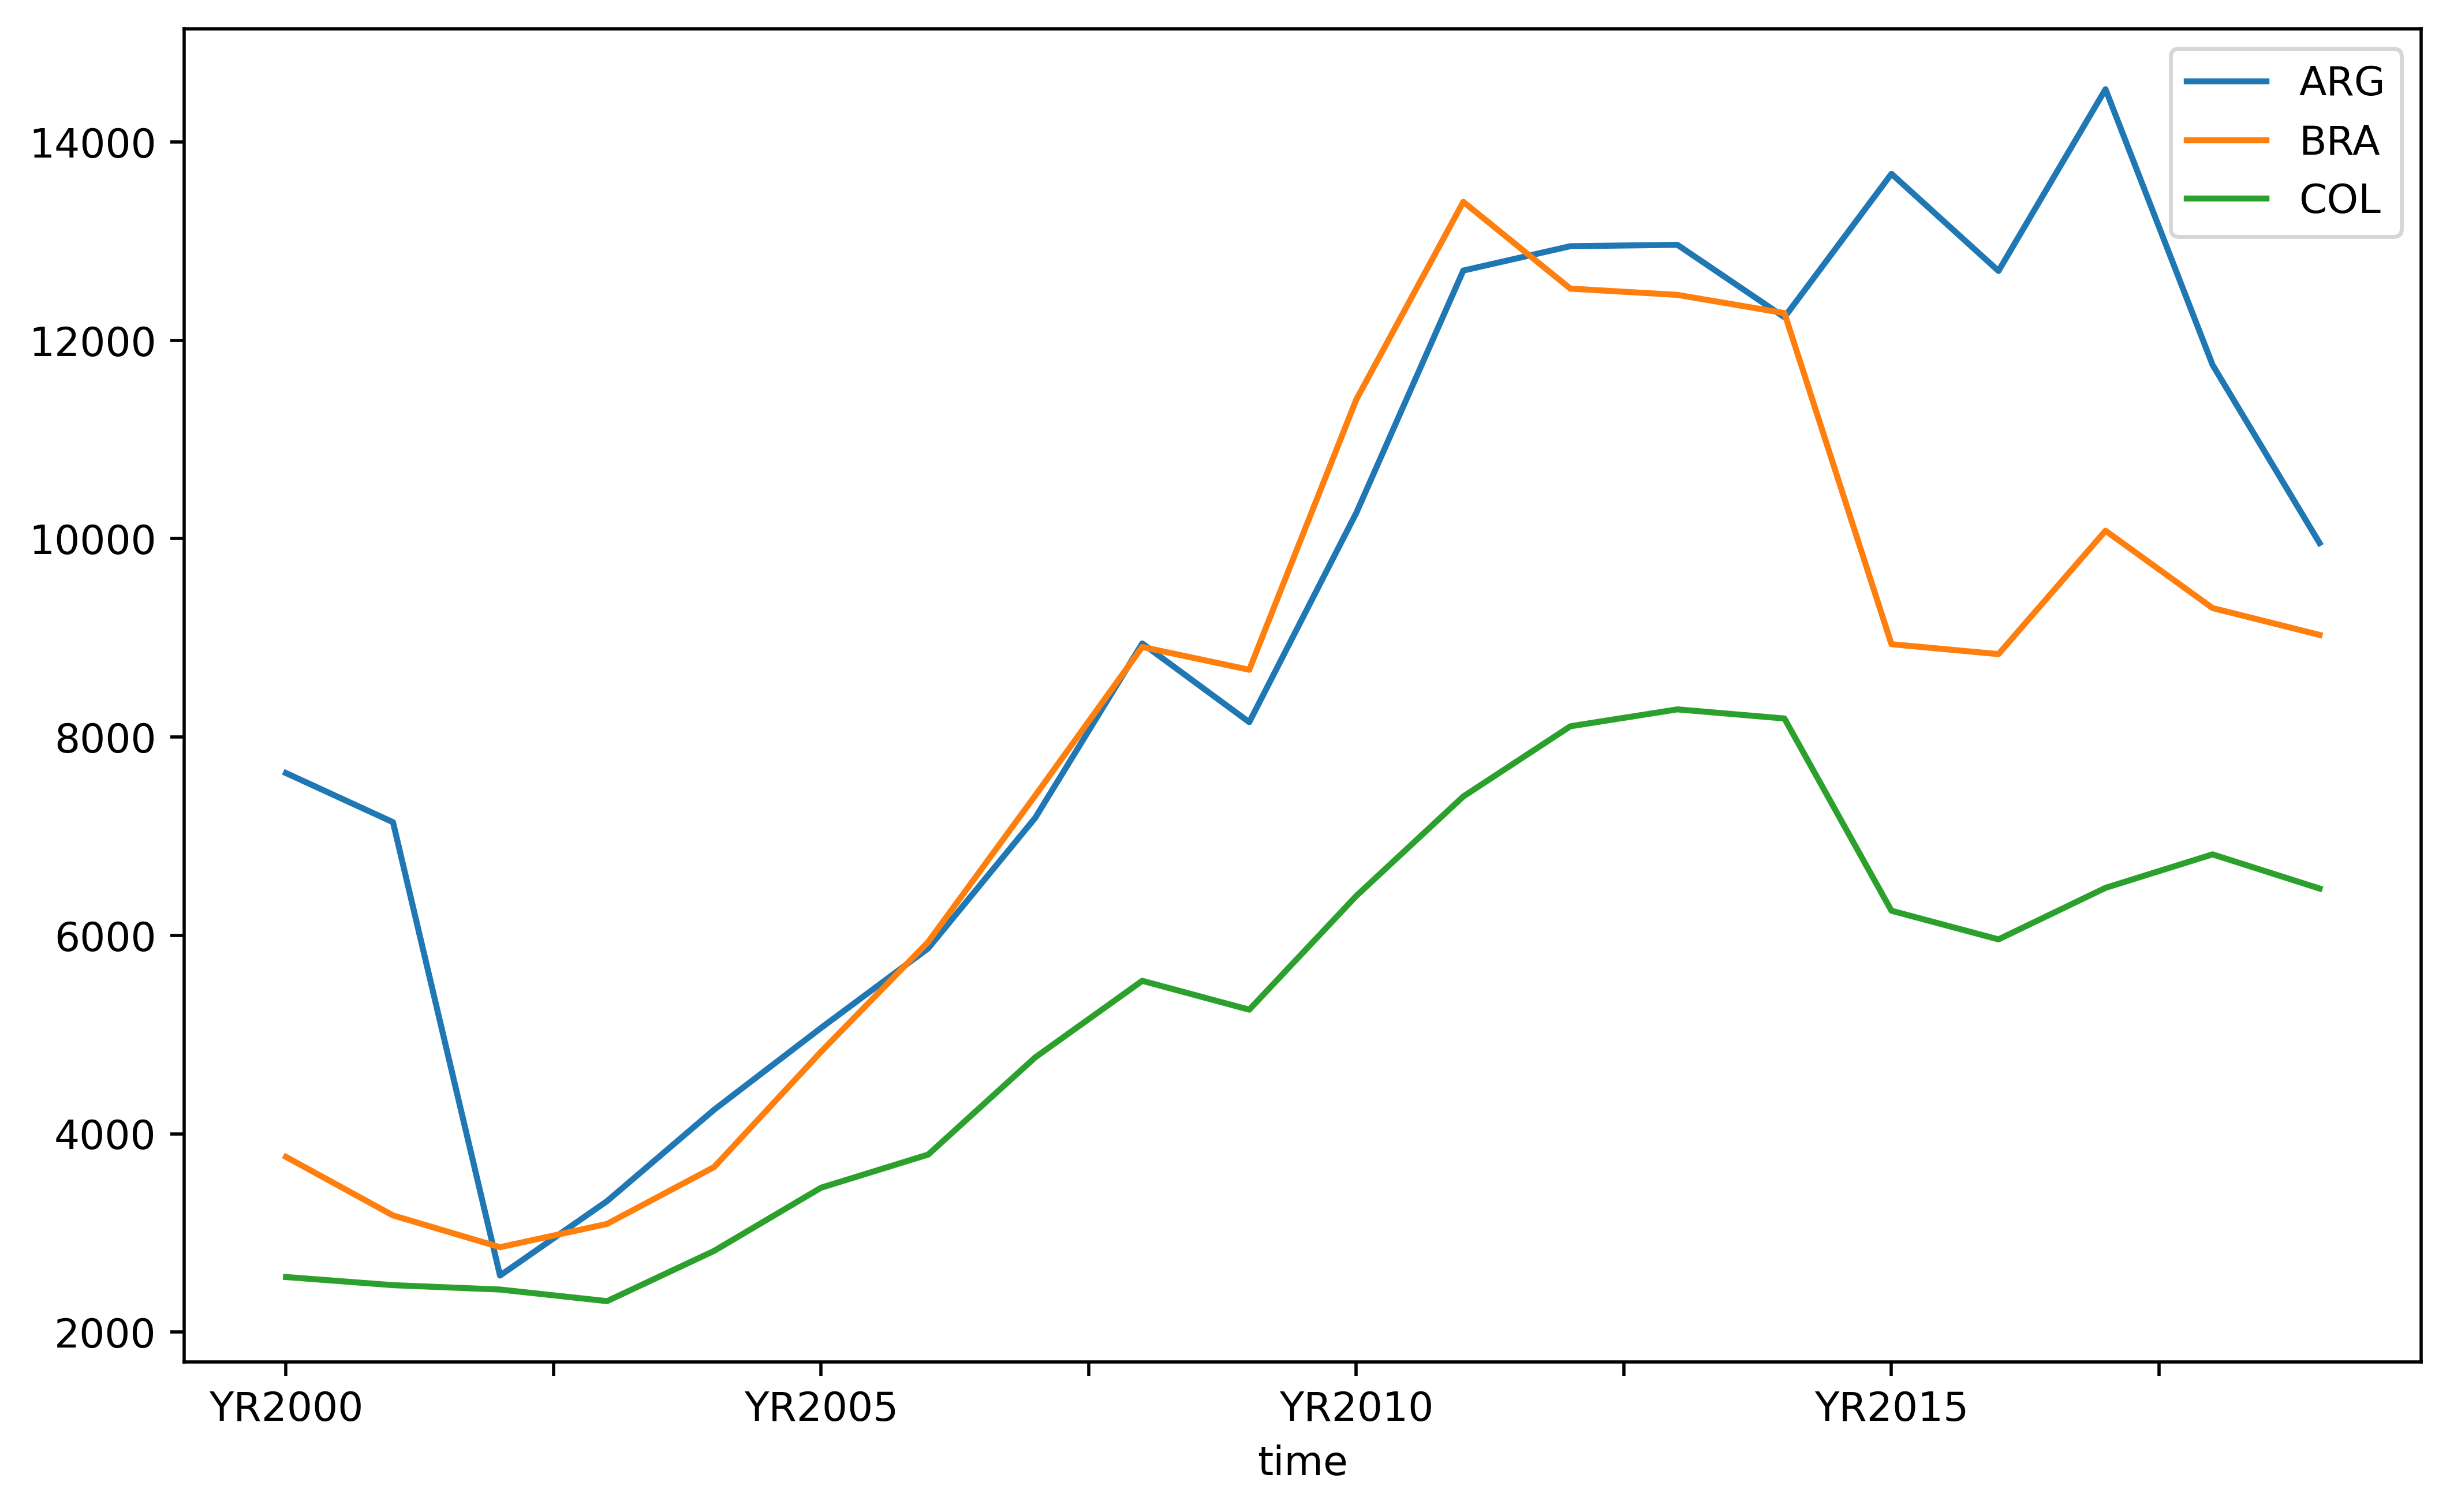

In [28]:
plt.rcParams['figure.dpi'] = 500  # 전역적으로 선명도(해상도)를 높인다.

wb.data.DataFrame('NY.GDP.PCAP.CD', ['BRA', 'ARG', 'COL'],
                  range(2000, 2020), index='time').plot(figsize=(10, 6))
plt.show()

### 빈곤인구비율 보고국 분포

빈곤인구비율(SI.POV.NAHC) 보고국이 연도별로 몇 개 나라인지를 막대그래프로 그려보자. `mrnev`(most recent non-empty values) 파라미터를 1로 설정하면, 데이터 프레임에 시간 차원이 포함되지 않는다. 그러나 `columns` 또는 `index` 파라미터를 사용하여 이를 명시적으로 요청할 수 있으며, `numericTimeKeys=True`을 사용해 시간 차원의 값을 숫자형으로 반환하도록 요청할 수 있다. 

In [29]:
wb.series.info('SI.POV.NAHC') # 국가 빈곤선 기준 빈곤 인구 비율 (전체 인구의 %)

id,value
SI.POV.NAHC,Poverty headcount ratio at national poverty lines (% of population)
,1 elements


In [30]:
df = wb.data.DataFrame('SI.POV.NAHC', mrnev=1, columns='time', numericTimeKeys=True)
df

,1993,2006,2007,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
economy,,,,,,,,,,,,,,,,,,,
AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.1,NaN,NaN,NaN,NaN,NaN
AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.3,NaN,NaN,NaN,NaN,NaN,NaN
ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.7,NaN,NaN
ARG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.1
ARM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.7,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
counts = df.count()
counts

1993     1
2006     1
2007     1
2009     2
2010     1
2011     3
2012     5
2013     1
2014     3
2015     5
2016     8
2017     7
2018    11
2019     9
2020     8
2021    32
2022    25
2023    21
2024    18
dtype: int64

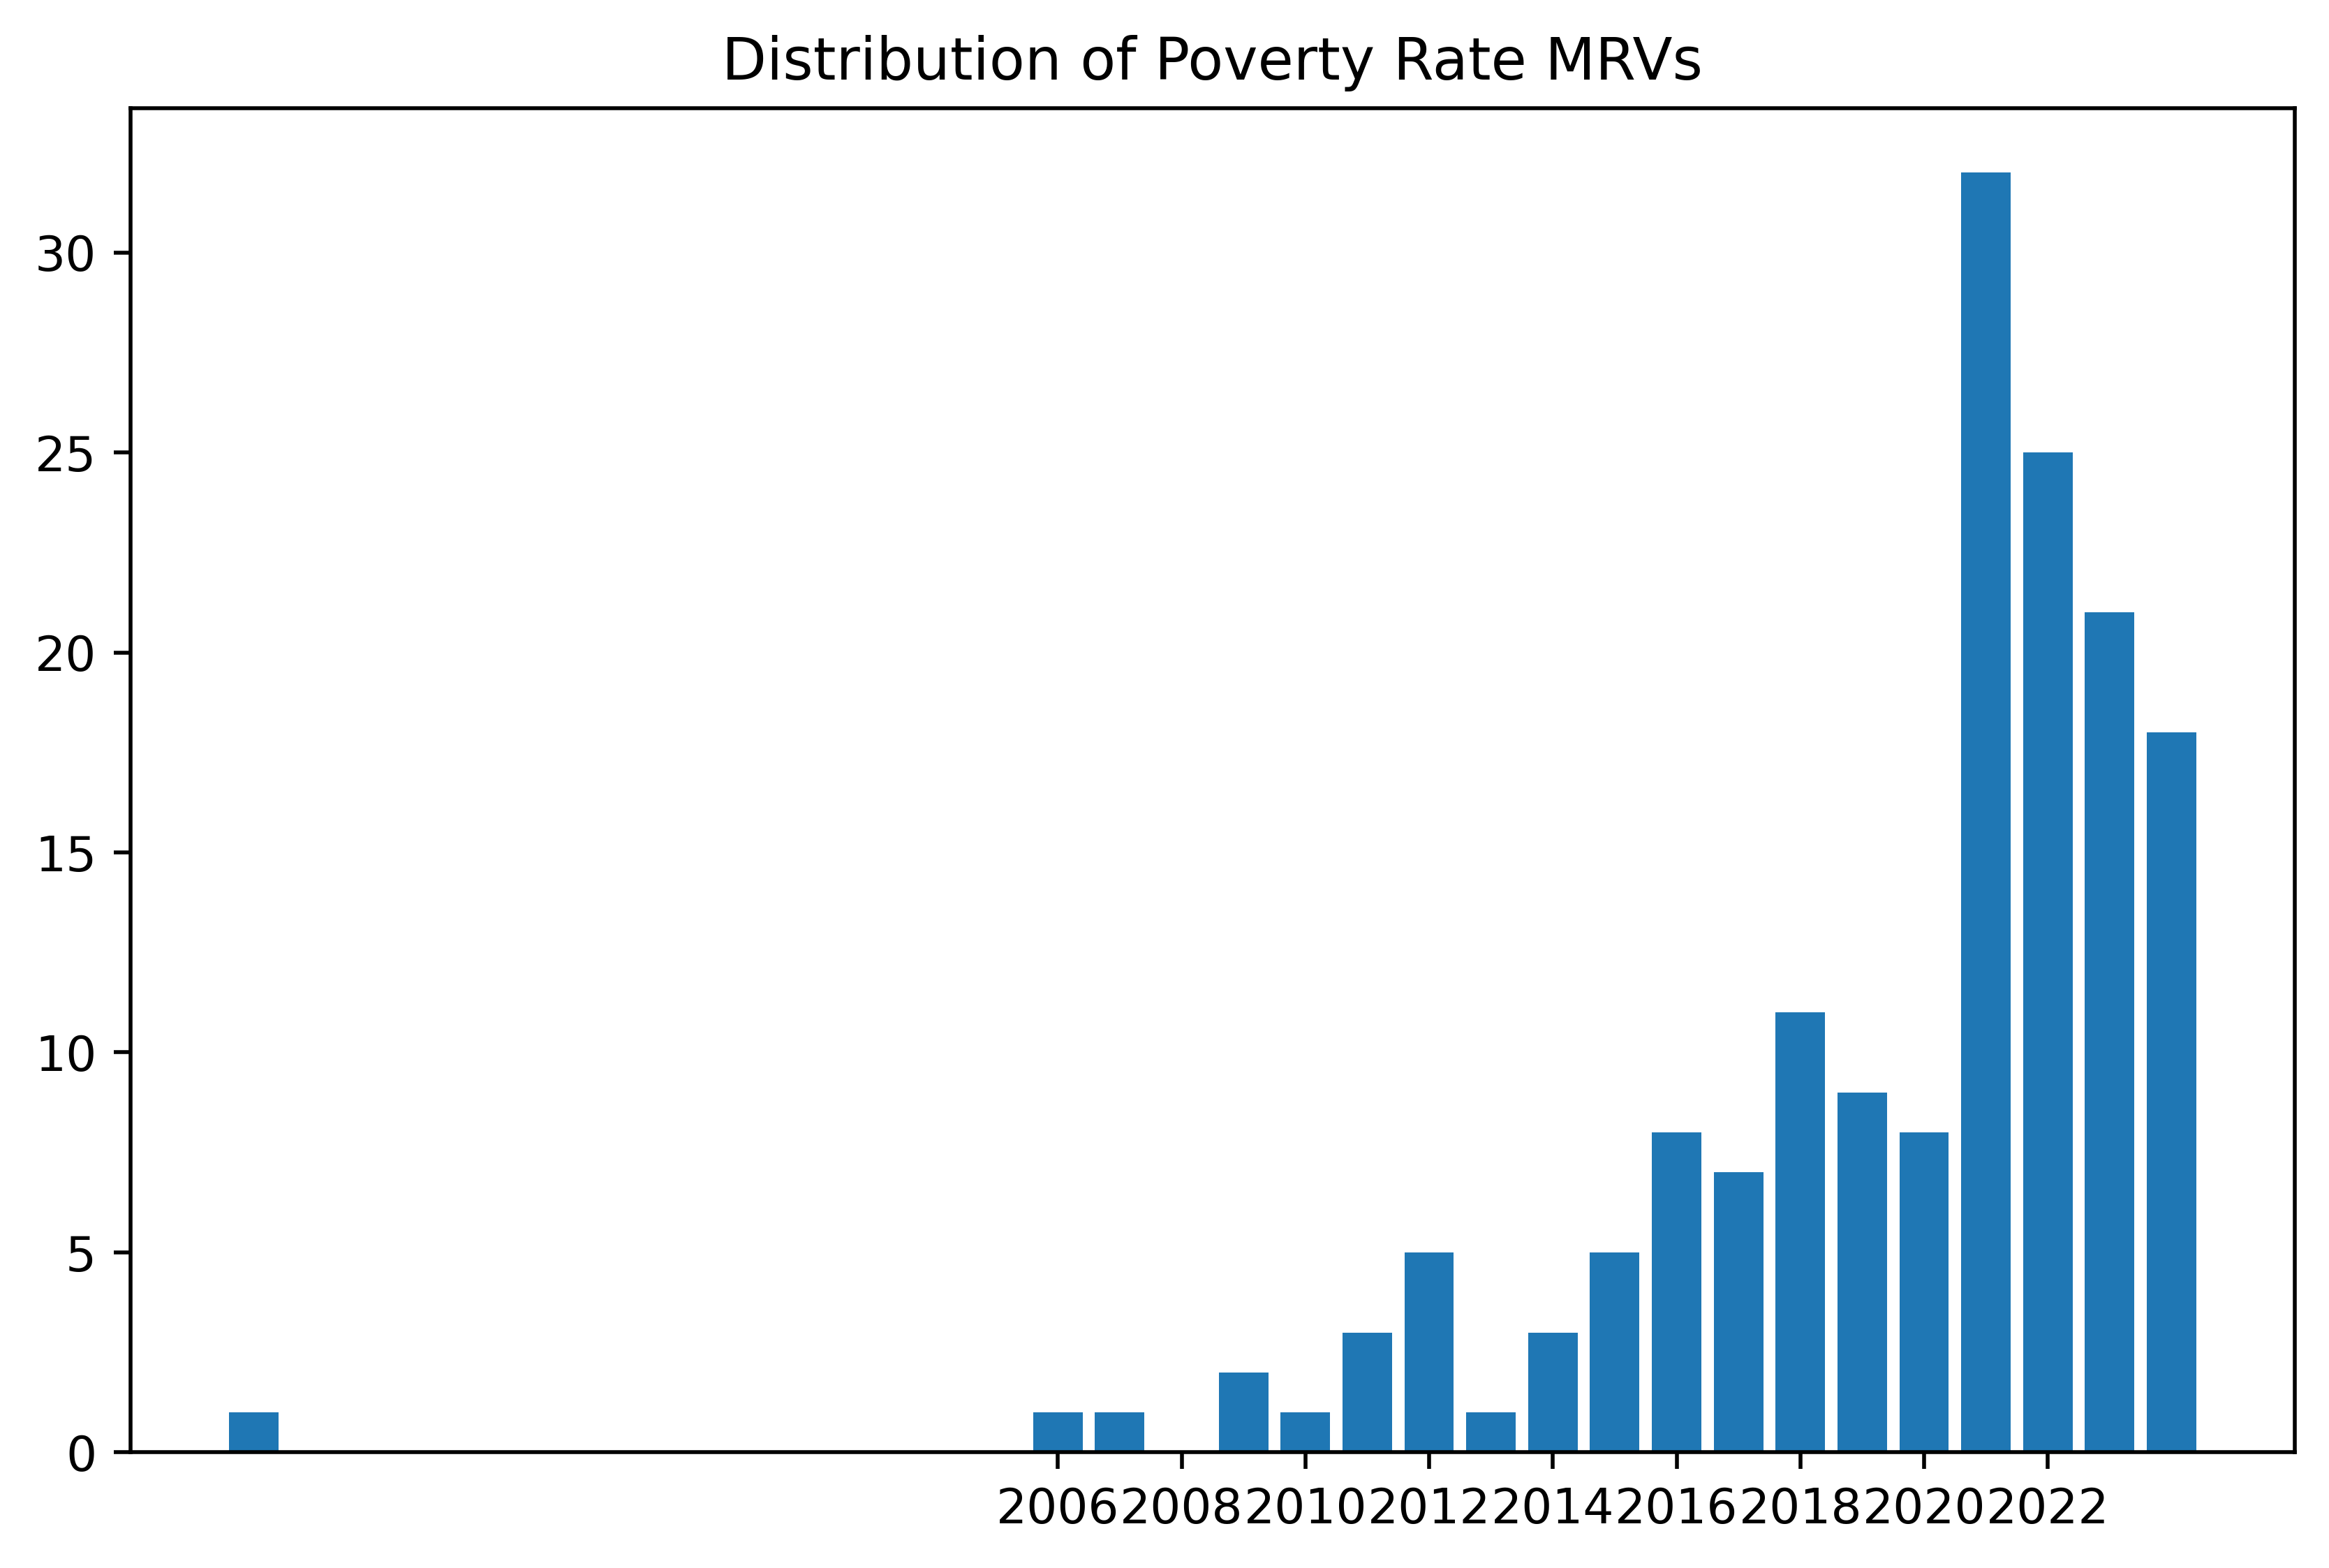

In [32]:
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts)
plt.xticks(np.arange(2006, 2023, 2))
plt.title('Distribution of Poverty Rate MRVs')
plt.show()

### 4차원 데이터베이스

대부분의 세계은행 데이터베이스는 series, economy and time의 3차원으로 구성되지만, WDI Archives와 같이 일부 데이터베이스는 4차원을 포함하고 있으며, 이전 버전의 지표들을 가져올 수 있다.

In [33]:
wb.source.info(57)

id,name,code,concepts,lastupdated
57,WDI Database Archives,WDA,4,2025-10-29
,1 elements,,,


In [34]:
wb.source.concepts(db=57)

{'economy': {'key': 'country', 'value': 'Country'},
 'series': {'key': 'series', 'value': 'Series'},
 'time': {'key': 'time', 'value': 'Time'},
 'version': {'key': 'version', 'value': 'Version'}}

In [35]:
wb.Series(wb.source.features('version', db=57))

198904    1989 Apr
199004    1990 Apr
199009    1990 Sep
199104    1991 Apr
199109    1991 Sep
            ...   
202501    2025 Jan
202503    2025 Mar
202504    2025 Apr
202506    2025 Jun
202507    2025 Jul
Name: value, Length: 136, dtype: object

브라질의 인구 추정치가 시간에 따라 수정되었는지 확인해보자. 이 예제에서는 `version` 파라미터가 WDI 개정판의 연도와 월을 지정한다. 버전 식별자는 YYYYMM 형식이기 때문에 201004에서 시작해 100 단위로 버전을 요청하면 요청한 범위에서 매년 4월 릴리스를 가져올 수 있다. 이를 통해 서로 다른 데이터베이스 버전 간의 값을 비교하여 변경되었는지 확인할 수 있다.


In [36]:
df = wb.data.DataFrame('SP.POP.TOTL', 'BRA', db=57, time=range(2000, 2020),
                       version=range(201004, 202004, 100), index='time')
df

,201004,201104,201204,201304,201404,201504,201604,201704,201804,201904
time,,,,,,,,,,
YR2000,174174447.0,174174447.0,174425387.0,174425387.0,174504898.0,174504898.0,175786441.0,175786441.0,175287587.0,175287587.0
YR2001,176659138.0,176659138.0,176877135.0,176877135.0,176968205.0,176968205.0,178419396.0,178419396.0,177750670.0,177750670.0
YR2002,179123364.0,179123364.0,179289227.0,179289227.0,179393768.0,179393768.0,181045592.0,181045592.0,180151021.0,180151021.0
YR2003,181537359.0,181537359.0,181633074.0,181633074.0,181752951.0,181752951.0,183627339.0,183627339.0,182482149.0,182482149.0
YR2004,183863524.0,183863524.0,183873377.0,183873377.0,184010283.0,184010283.0,186116363.0,186116363.0,184738458.0,184738458.0
YR2005,186074634.0,186074634.0,185986964.0,185986964.0,186142403.0,186142403.0,188479240.0,188479240.0,186917361.0,186917361.0
YR2006,188158438.0,188158438.0,187958211.0,187958211.0,188134315.0,188134315.0,190698241.0,190698241.0,189012412.0,189012412.0
YR2007,190119995.0,190119995.0,189798070.0,189798070.0,189996976.0,189996976.0,192784521.0,192784521.0,191026637.0,191026637.0
YR2008,191971506.0,191971506.0,191543237.0,191543237.0,191765567.0,191765567.0,194769696.0,194769696.0,192979029.0,192979029.0


In [37]:
ax = df.plot(figsize=(10, 6), title="Population estimates over time by WDI version")

### 집계

`pandas`에서는 집계(aggregation)가 매우 간단하다. 예를 들어, 평균값은 다음과 같이 구한다.

    df.mean()
    
아래에서는 예시적으로 브라질, 콜롬비아, 페루 3개국의 1990년부터 1995년에 걸친 `EG.ELC.ACCS.ZS`(전기접근성, 전체 인구의 %) 지표에 대해 각 연도별로 3개국의 평균값을 구해보자.

In [38]:
wb.series.info(['EG.ELC.ACCS.ZS'])

id,value
EG.ELC.ACCS.ZS,Access to electricity (% of population)
,1 elements


In [39]:
wb.economy.info(['BRA', 'COL', 'PER'])

id,value,region,incomeLevel
BRA,Brazil,LCN,UMC
COL,Colombia,LCN,UMC
PER,Peru,LCN,UMC
,3 elements,,


In [40]:
df = wb.data.DataFrame('EG.ELC.ACCS.ZS', ['BRA', 'COL', 'PER'], time=range(1990,1996))
df

,YR1990,YR1991,YR1992,YR1993,YR1994,YR1995
economy,,,,,,
BRA,87.475116,90.606544,88.803833,89.999927,91.883728,91.728598
COL,89.900000,91.836655,92.132660,92.427994,92.721962,91.200000
PER,NaN,NaN,70.100000,64.748993,66.052933,67.354836


In [41]:
df.mean()

YR1990    88.687558
YR1991    91.221600
YR1992    83.678831
YR1993    82.392305
YR1994    83.552874
YR1995    83.427811
dtype: float64

**가중 평균**

여기서는 예시적으로 인구를 가중치로 사용한다. 가중치를 적용할 값들과 동일한 차원을 가진 인구(`SP.POP.TOTL`) 데이터 프레임이 필요하다. 가장 간단한 방법은 동일한 economy와 time에 대해 두 지표를 단일의 데이터 프레임으로 만드는 것이다. 이 경우, 다음과 같은 방식으로 `index` 파라미터를 사용하여 다중 인덱스를 가진 데이터 프레임을 생성하면 된다.

In [42]:
combined = wb.data.DataFrame(['EG.ELC.ACCS.ZS', 'SP.POP.TOTL'], ['BRA', 'COL', 'PER'],
                             time=range(1990,1996), index=['series', 'economy'])
combined

YR1990        YR1991        YR1992  \
series         economy                                             
EG.ELC.ACCS.ZS BRA      8.747512e+01  9.060654e+01  8.880383e+01   
               COL      8.990000e+01  9.183665e+01  9.213266e+01   
               PER               NaN           NaN  7.010000e+01   
SP.POP.TOTL    BRA      1.491432e+08  1.517243e+08  1.542751e+08   
               COL      3.244007e+07  3.309837e+07  3.376057e+07   
               PER      2.201477e+07  2.248378e+07  2.294634e+07   

                              YR1993        YR1994        YR1995  
series         economy                                            
EG.ELC.ACCS.ZS BRA      8.999993e+01  9.188373e+01  9.172860e+01  
               COL      9.242799e+01  9.272196e+01  9.120000e+01  
               PER      6.474899e+01  6.605293e+01  6.735484e+01  
SP.POP.TOTL    BRA      1.567946e+08  1.592650e+08  1.617351e+08  
               COL      3.444147e+07  3.512741e+07  3.580466e+07  
               PER      2.341378e+07  2.388149e+07  2.434892e+07

그런 다음, 집계 변수(`EG.ELC.ACCS.ZS`)에서 NaN으로 돼있는 관측값에 대해 가중치 변수(`SP.POP.TOTL`)에도 이들을 마스킹(제외) 처리해야 한다. 그렇지 않으면 가중 평균 계산에서 분모가 잘못 계산된다. 

In [43]:
elec_access = combined.xs('EG.ELC.ACCS.ZS') # 집계 변수 데이터 프레임
combined = combined[elec_access.isna() == False] # 다른 변수들에서 NaN 값을 마스킹 처리함
combined

YR1990        YR1991        YR1992  \
series         economy                                             
EG.ELC.ACCS.ZS BRA      8.747512e+01  9.060654e+01  8.880383e+01   
               COL      8.990000e+01  9.183665e+01  9.213266e+01   
               PER               NaN           NaN  7.010000e+01   
SP.POP.TOTL    BRA      1.491432e+08  1.517243e+08  1.542751e+08   
               COL      3.244007e+07  3.309837e+07  3.376057e+07   
               PER               NaN           NaN  2.294634e+07   

                              YR1993        YR1994        YR1995  
series         economy                                            
EG.ELC.ACCS.ZS BRA      8.999993e+01  9.188373e+01  9.172860e+01  
               COL      9.242799e+01  9.272196e+01  9.120000e+01  
               PER      6.474899e+01  6.605293e+01  6.735484e+01  
SP.POP.TOTL    BRA      1.567946e+08  1.592650e+08  1.617351e+08  
               COL      3.444147e+07  3.512741e+07  3.580466e+07  
               PER      2.341378e+07  2.388149e+07  2.434892e+07

이렇게 하면, 가중치가 적용된 값의 합을 가중치의 합으로 나눈 가중 평균을 쉽게 계산할 수 있다.

In [44]:
elec_access = combined.xs('EG.ELC.ACCS.ZS')
pop = combined.xs('SP.POP.TOTL')
(elec_access*pop).sum() / pop.sum()

YR1990    87.908324
YR1991    90.826835
YR1992    87.302276
YR1993    87.635175
YR1994    89.192463
YR1995    88.968650
dtype: float64

### 그룹 집계

그룹 집계는 앞서 설명한 방법을 확장한 것이다. 평균을 계산하기 전에, 그룹을 정의하는 변수(예: 국가 이름의 첫 글자)를 기준으로 지표 데이터 프레임들을 결합하면 된다. 여기서는 국가 이름의 첫 글자를 기준으로 간단한 그룹을 정의해보자. 첫 번째 단계로, 국가의 첫 글자들로 이루어진 pandas 시리즈를 생성해야 한다.


In [45]:
c = wb.economy.DataFrame()
c['Initial'] = c['name'].str[0]
initial = c['Initial']

# another way to the same thing
initial = wb.economy.Series(name='Initial').apply(lambda n: n[0])
initial

ABW    A
AFE    A
AFG    A
AFW    A
AGO    A
      ..
XKX    K
YEM    Y
ZAF    S
ZMB    Z
ZWE    Z
Name: Initial, Length: 266, dtype: object

In [46]:
# 모든 국가를 불러온다. World나 Sub-Saharan Africa와 같은 집계 지역은 제외한다(skipAggs=True).
combined = wb.data.DataFrame(['EG.ELC.ACCS.ZS', 'SP.POP.TOTL'], skipAggs=True,
                             time=range(1990, 1996), index=['series', 'economy'])
elec_access = combined.xs('EG.ELC.ACCS.ZS')

# 집계 변수에 없는 가중치 변수의 관측값을 마스킹 처리한다.
combined = combined[elec_access.isna() == False]

pop = combined.xs('SP.POP.TOTL')

numerator   = (elec_access * pop).join(initial).groupby('Initial').sum()
denominator = pop.join(initial).groupby('Initial').sum()

numerator / denominator

,YR1990,YR1991,YR1992,YR1993,YR1994,YR1995
Initial,,,,,,
A,95.780387,95.952820,96.126616,96.297750,96.468972,96.640102
B,89.838599,62.530803,59.826296,59.682781,62.342033,62.355179
C,95.191828,88.595383,88.954841,89.166747,83.116034,81.322167
D,100.000000,87.222188,89.663119,90.051993,90.447886,90.856901
E,100.000000,76.332513,92.076353,93.946373,94.263941,91.881157
F,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
G,99.999760,99.999807,99.999854,88.494521,88.253563,86.068557
H,100.000000,89.096623,89.898608,90.270005,91.039354,76.030206
I,100.000000,62.177695,75.262775,54.384301,54.690727,56.554949


## 3. 구매력평가 환율 데이터

### PPP 관련 지표
- WDI(World Development Indicators) 데이터베이스에서 PPP 관련 지표

| Indicator        | English Description                                                        | Korean Translation                                         |
|------------------|----------------------------------------------------------------------------|------------------------------------------------------------|
| PA.NUS.FCRF      | Official exchange rate (LCU per USD, period average)                     | 공식 환율 (LCU per USD, 기간 평균)                          |
| PA.NUS.PPP       | PPP conversion factor, GDP (LCU per international dollar)                     | GDP에 대한 PPP 환산계수 (LCU per 국제 달러)                 |
| PA.NUS.PPPC.RF   | Price level ratio of PPP conversion factor (GDP) to market exchange rate   | PPP 환산계수(GDP)와 시장 환율 간의 물가 수준 비율           |
| PA.NUS.PRVT.PP   | PPP conversion factor, private consumption (LCU per international dollar)       | 개인 소비에 대한 PPP 환산계수 (LCU per 국제 달러)           |


### 한국 PPP 관련 데이터

In [47]:
df = wb.data.DataFrame(
    ['PA.NUS.FCRF', 'PA.NUS.PPP', 'PA.NUS.PPPC.RF', 'PA.NUS.PRVT.PP'],
    'KOR', columns='time', numericTimeKeys=True).T  # 모든 연도에 대해
df

series,PA.NUS.FCRF,PA.NUS.PPP,PA.NUS.PPPC.RF,PA.NUS.PRVT.PP
1960,63.125000,NaN,NaN,NaN
1961,124.791667,NaN,NaN,NaN
1962,130.000000,NaN,NaN,NaN
1963,130.000000,NaN,NaN,NaN
1964,213.846667,NaN,NaN,NaN
...,...,...,...,...
2020,1180.265833,829.359157,0.702688,971.479342
2021,1143.951667,829.867766,0.725440,960.988192
2022,1291.446667,816.607833,0.632320,933.201393
2023,1305.662500,828.391665,0.634461,932.176827


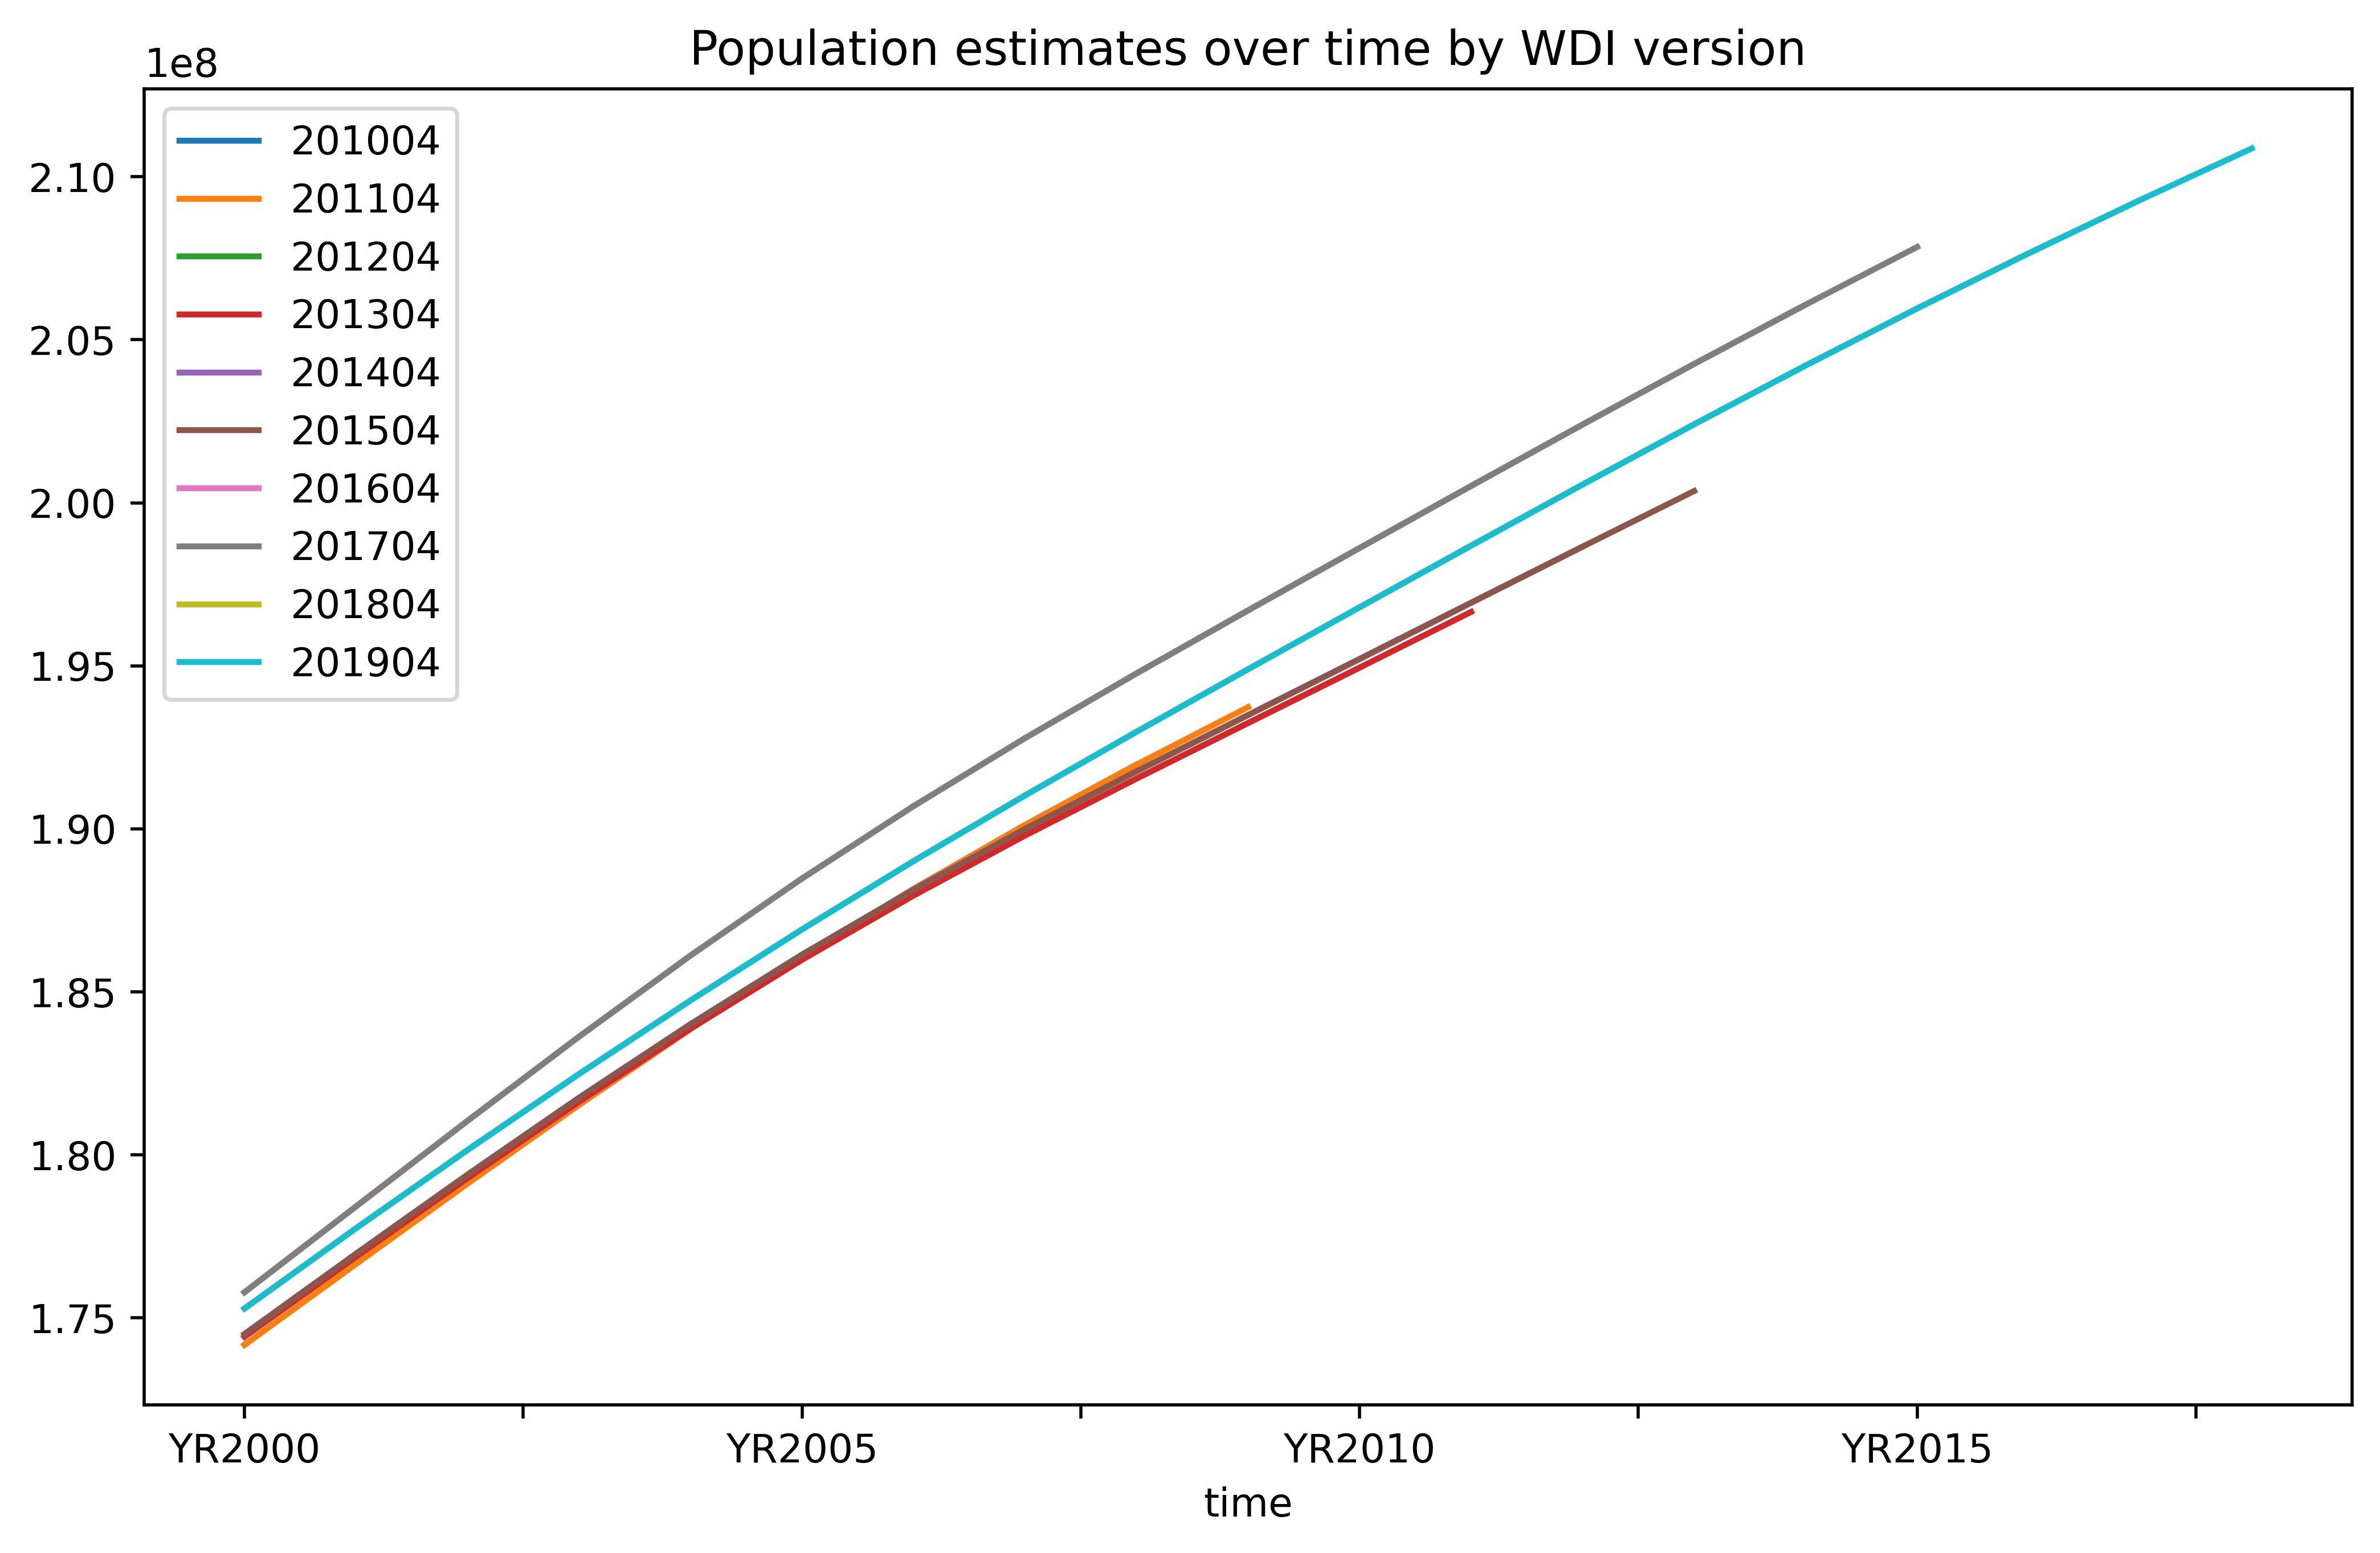

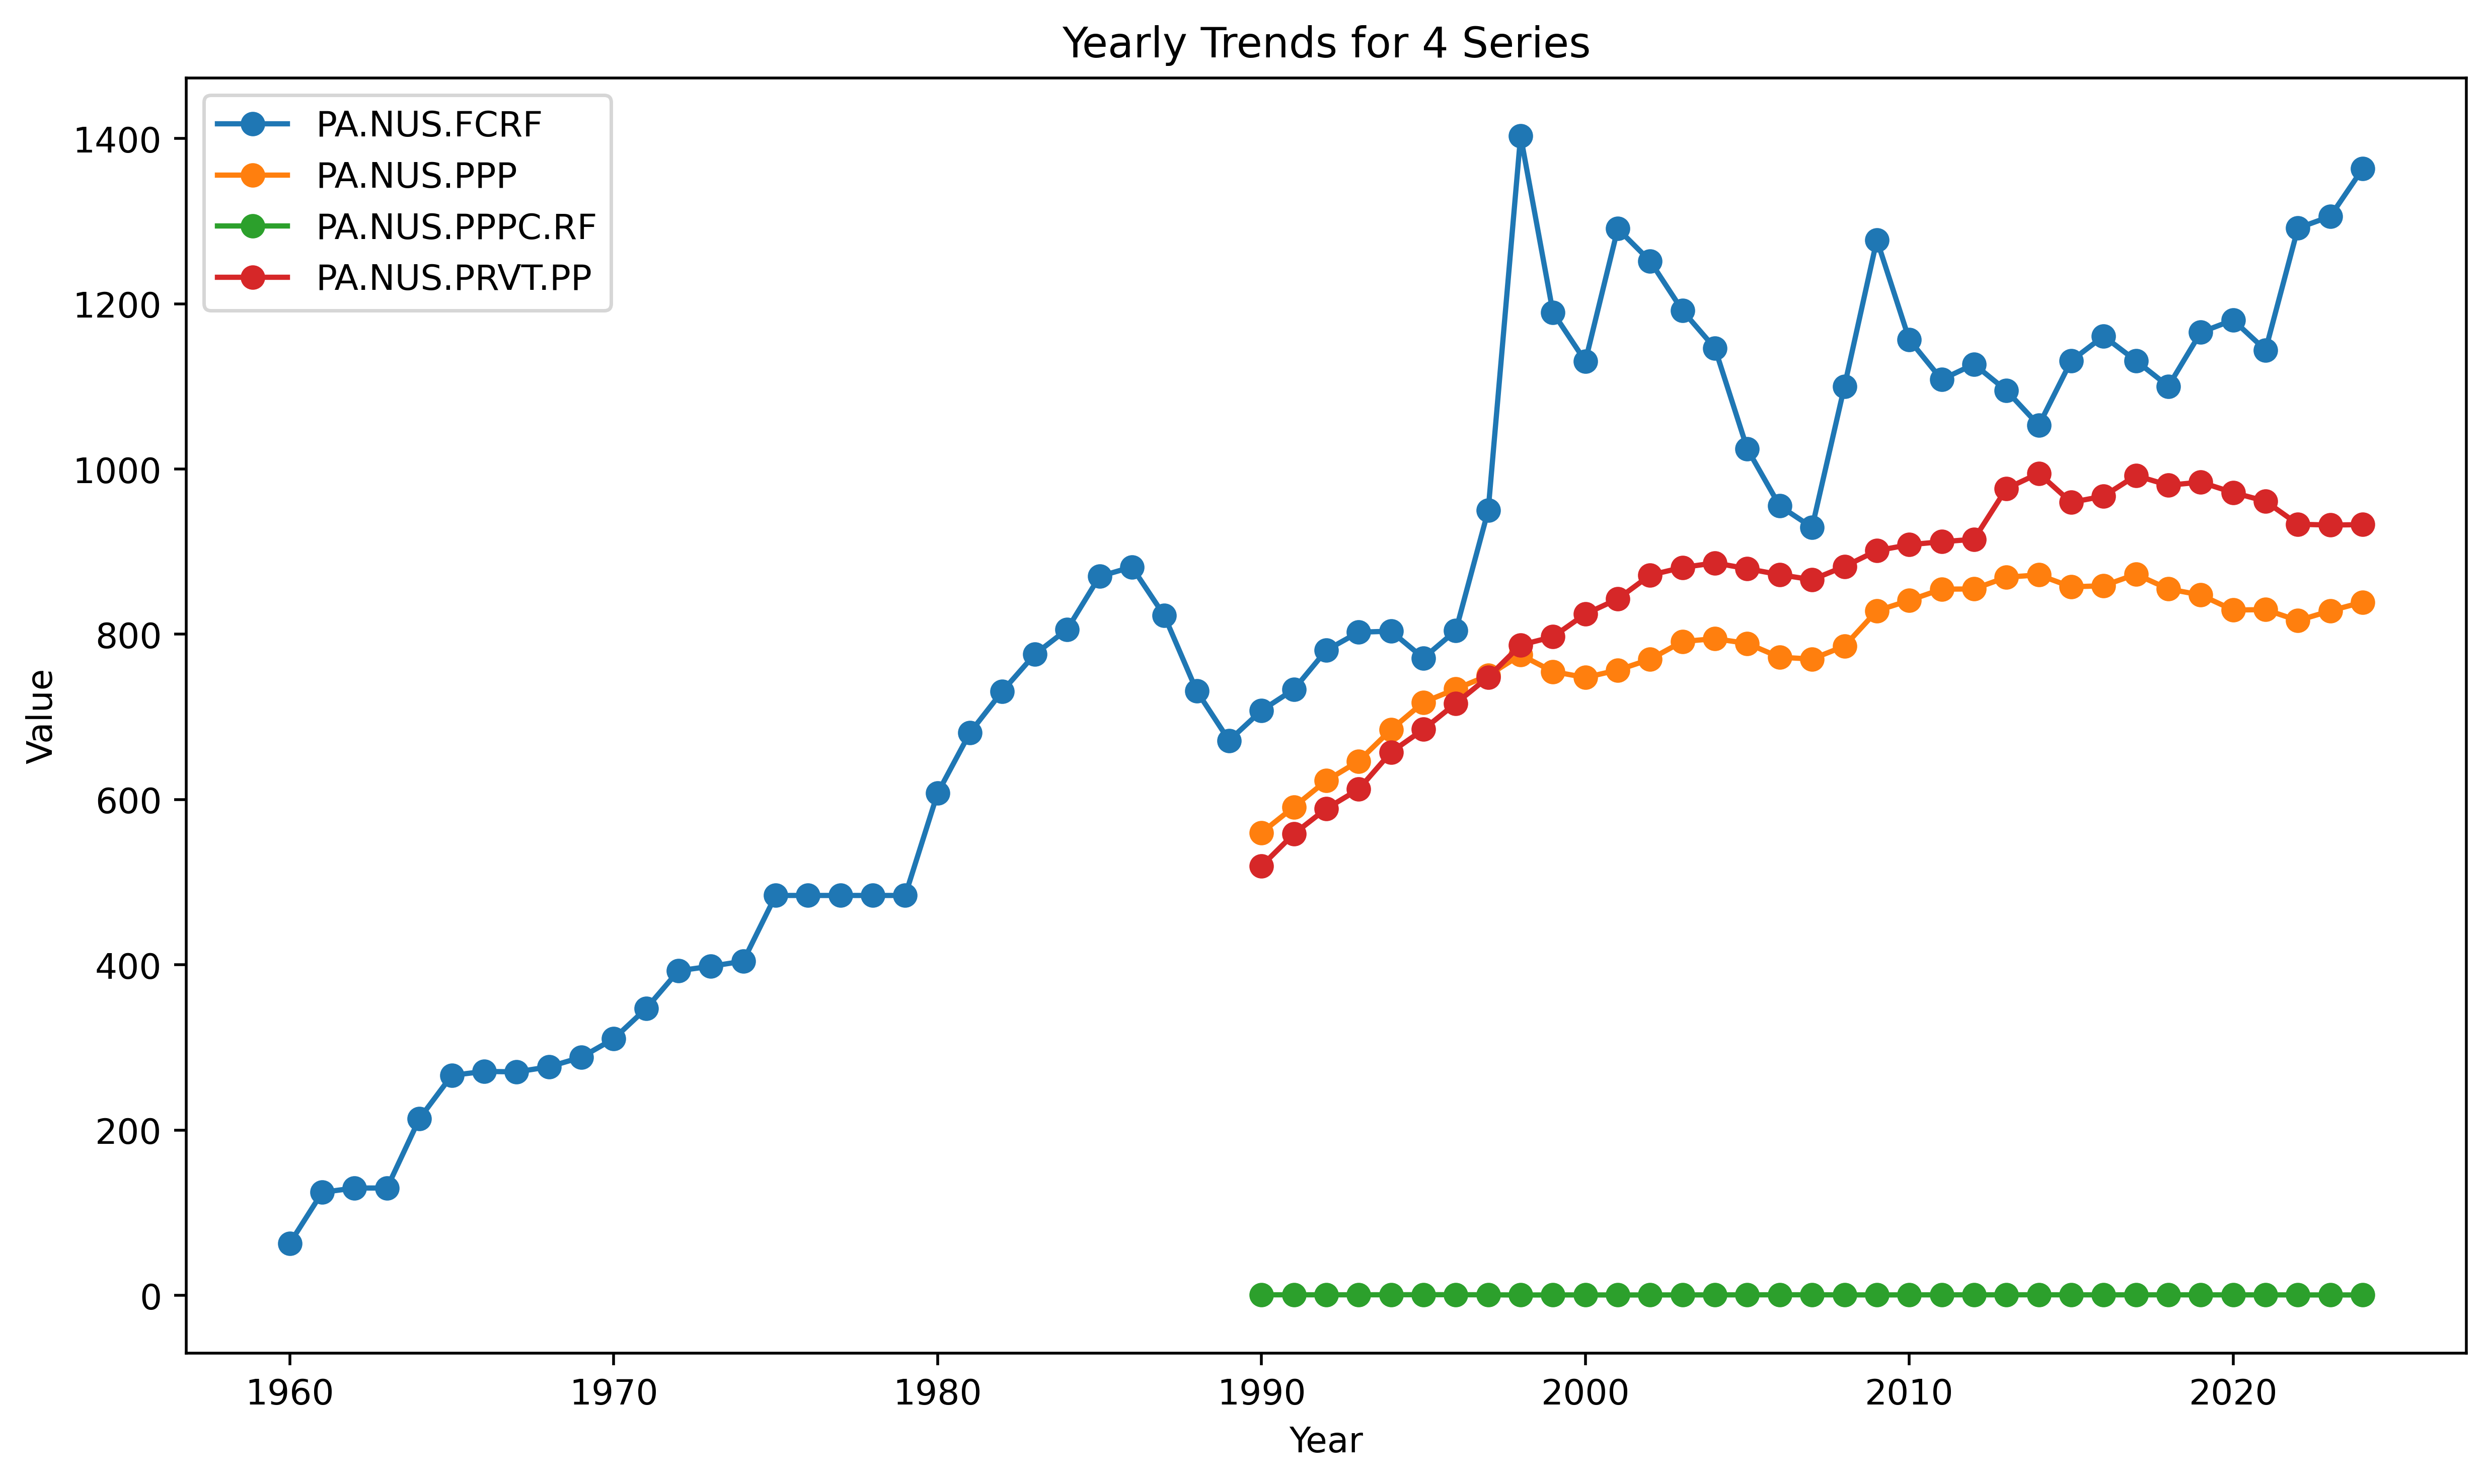

In [48]:
plt.figure(figsize=(10, 6))
for series in df.columns:
    plt.plot(df.index, df[series], marker='o', label=series)

plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Yearly Trends for 4 Series')
plt.legend()
plt.tight_layout()
plt.show()

### 한국 명목환율 및 PPP 환율 추이

In [49]:
df_sub = df[['PA.NUS.FCRF', 'PA.NUS.PPP', 'PA.NUS.PRVT.PP']]
df_sub.columns = ['Official exchange rate', 
                  'PPP conversion factor (GDP)', 
                  'PPP conversion factor (private consumption)']
df_sub = df_sub[df_sub.index.astype(int) >= 1990]

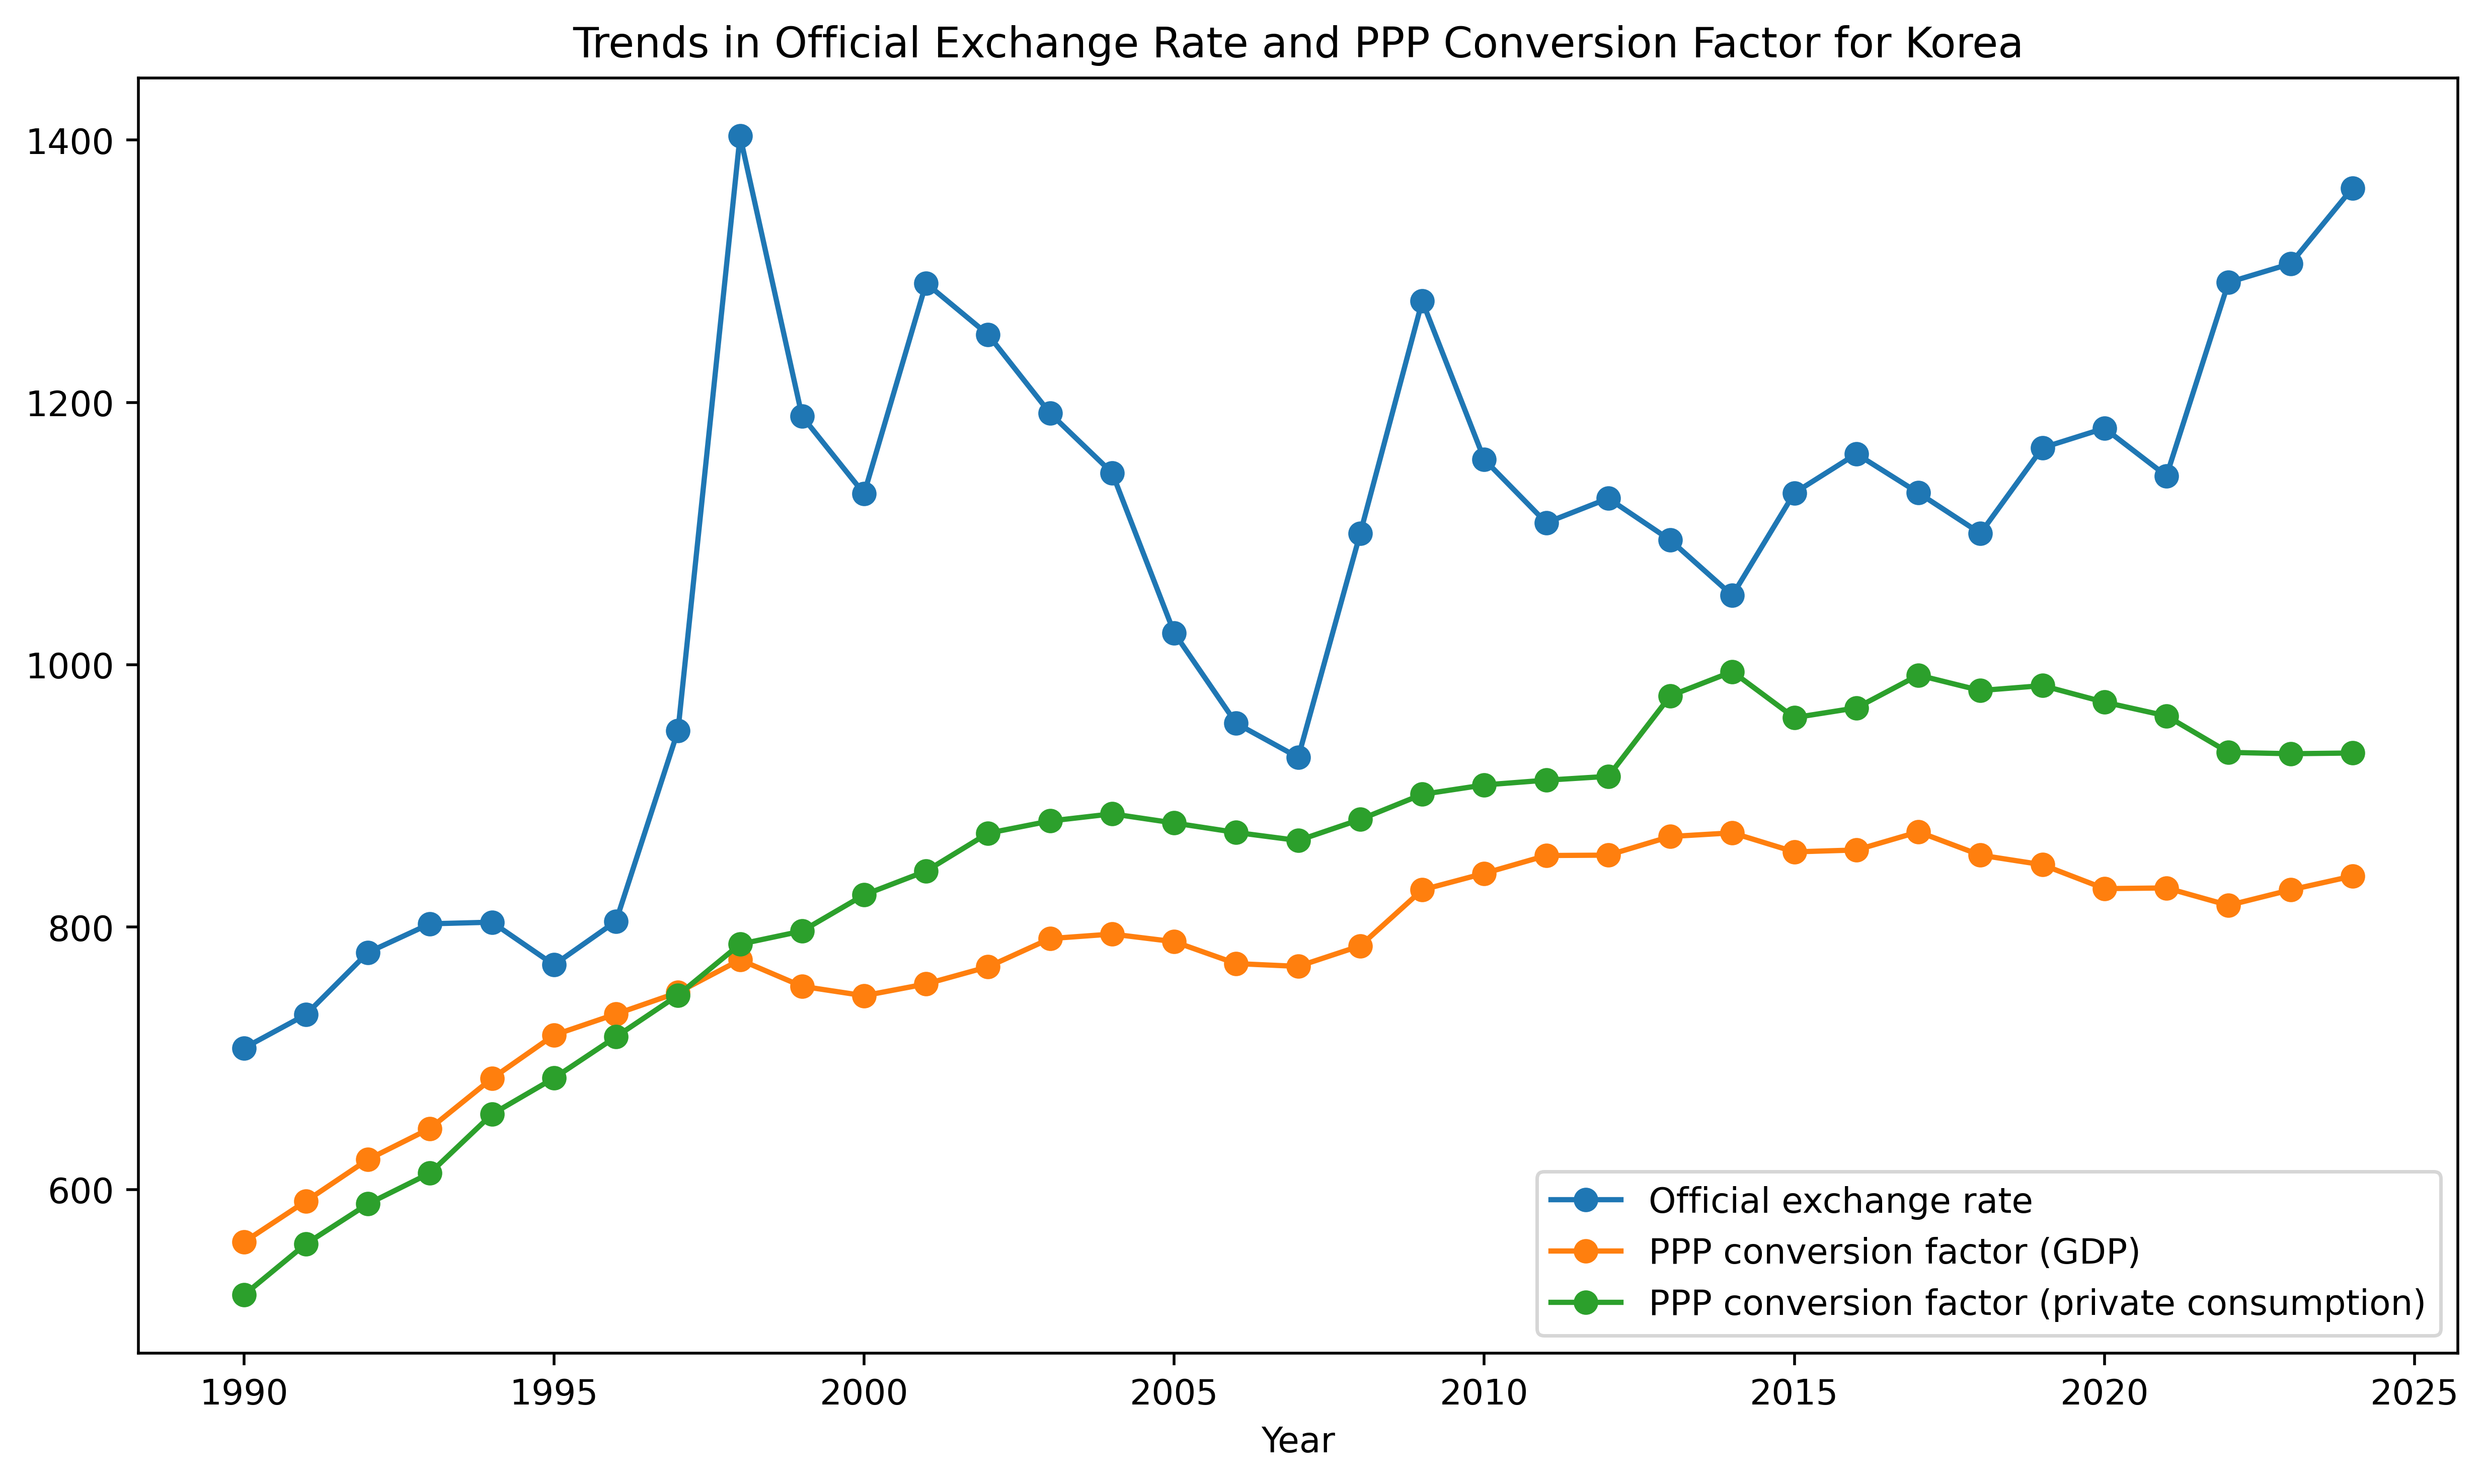

In [50]:
plt.figure(figsize=(10, 6))
for series in df_sub.columns:
    plt.plot(df_sub.index, df_sub[series], marker='o', label=series)

plt.xlabel('Year')
plt.title('Trends in Official Exchange Rate and PPP Conversion Factor for Korea')
plt.legend()
plt.tight_layout()
plt.show()